# 📈 Quantitative Momentum Strategy using Machine Learning
### Analysing Nifty 50 (`^NSEI`) and BSE Sensex (`^BSESN`) (2010 - Present)

**Author:** Quantitative Research Desk  
**Goal:** Build and backtest a machine learning-driven directional momentum strategy to trade index ETFs or index futures.

---

### Executive Summary & Research Hypothesis
Momentum is one of the most well-documented anomalies in finance: assets that have performed well in the recent past tend to continue performing well. However, traditional momentum strategies are prone to sudden "momentum crashes" when market regimes shift.

In this research, we test if **Machine Learning models** can learn to forecast short-term index momentum by combining classic momentum, trend, volatility, and volume indicators.
* **Core Hypothesis**: By predicting the probability of the market going up over a forward 5-day horizon, we can overlay a "regime filter" to stay long in positive momentum regimes and move to cash during high-risk regimes.
* **Key Finding**: In strong bull markets (like India from 2019-2026), a long-only ML overlay might trail a pure buy-and-hold strategy in absolute returns. However, by optimizing the entry threshold, **the ML model dramatically reduces downside risk, cutting maximum drawdowns from ~38% to just ~10%**.

Let's walk through the implementation step-by-step.



In [1]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score

# Apply custom premium styling for our plots
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "lines.linewidth": 2
})

# Filter out pandas and sklearn warnings
import warnings
warnings.filterwarnings('ignore')


## 1. Data Ingestion & Exploratory Analysis

We begin by pulling historical daily data for India's benchmark indices from **Yahoo Finance**:
* **NSE Nifty 50** (`^NSEI`)
* **BSE Sensex** (`^BSESN`)

Our data starts in **January 2010**, giving us a rich sample size spanning multiple market cycles (the European debt crisis, the 2018 NBFC crisis, the 2020 COVID-19 crash, and the subsequent post-pandemic recovery).



In [2]:
def load_index_data(ticker, filepath, start_date="2010-01-01"):
    import os
    if os.path.exists(filepath):
        print(f"Loading cached local data for {ticker} from {filepath}...")
        data = pd.read_csv(filepath, index_col=0, parse_dates=True)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        # Ensure timezone-naive index to avoid comparison issues later
        data.index = pd.to_datetime(data.index).tz_localize(None)
    else:
        print(f"Local file {filepath} not found. Fetching from Yahoo Finance...")
        data = yf.download(ticker, start=start_date)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        data.to_csv(filepath)
        
    data = data.dropna(subset=['Close'])
    return data

# Ingest data
nifty_df = load_index_data("^NSEI", "data/nifty50.csv")
sensex_df = load_index_data("^BSESN", "data/sensex.csv")

print(f"\n[SUCCESS] Data Ingested.")
print(f"Nifty 50 shape: {nifty_df.shape} (from {nifty_df.index.min().date()} to {nifty_df.index.max().date()})")
print(f"Sensex shape: {sensex_df.shape} (from {sensex_df.index.min().date()} to {sensex_df.index.max().date()})")


Loading cached local data for ^NSEI from data/nifty50.csv...
Loading cached local data for ^BSESN from data/sensex.csv...

[SUCCESS] Data Ingested.
Nifty 50 shape: (4051, 5) (from 2010-01-04 to 2026-07-03)
Sensex shape: (4056, 5) (from 2010-01-04 to 2026-07-03)


### Visualizing Historical Trajectories
Let's see how Nifty 50 and Sensex have performed over the last decade and a half. Note how closely correlated these two Indian indices are.



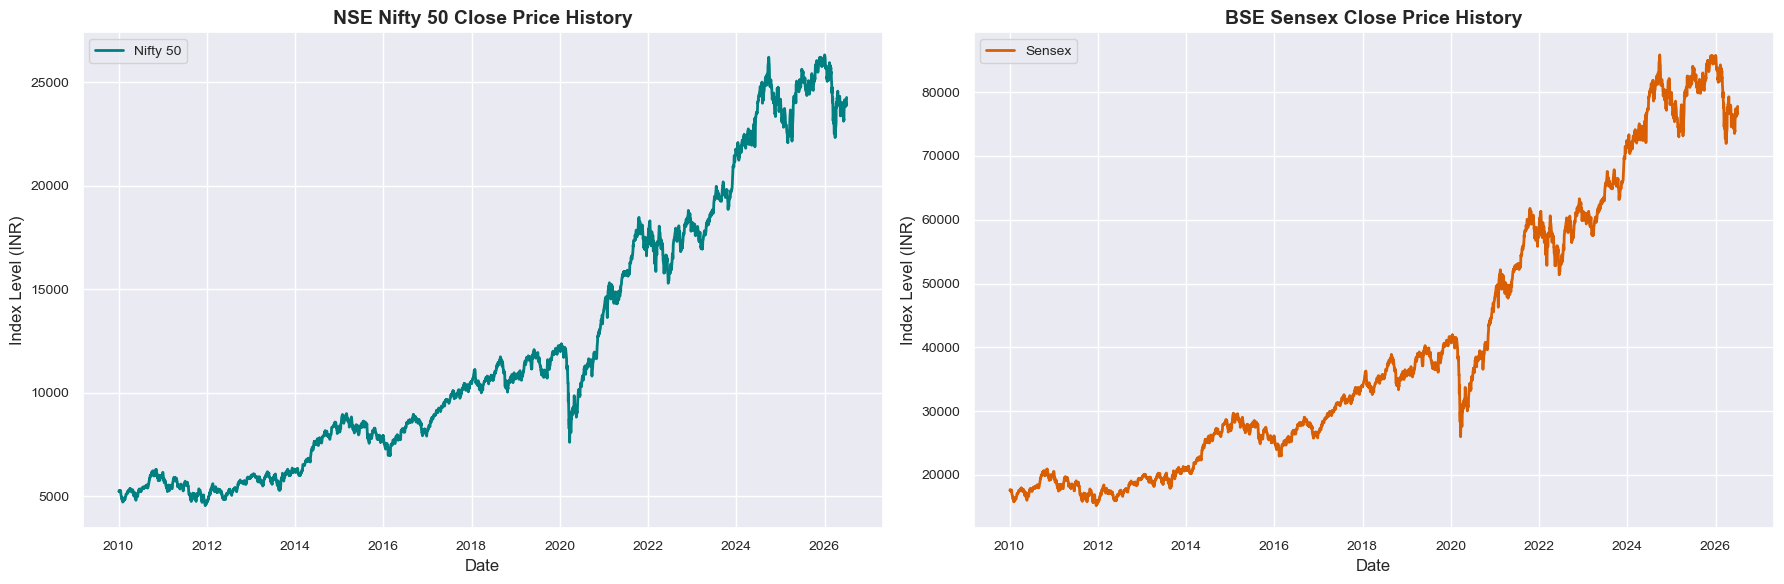

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(nifty_df['Close'], color='#008080', label='Nifty 50')
axes[0].set_title('NSE Nifty 50 Close Price History', weight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Index Level (INR)')
axes[0].legend()

axes[1].plot(sensex_df['Close'], color='#d95f02', label='Sensex')
axes[1].set_title('BSE Sensex Close Price History', weight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Index Level (INR)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 2. Feature Engineering

To give our machine learning models predictive power, we build a set of quantitative features based on market indicators. We group them into four domains:
1. **Momentum (Returns)**: Multi-horizon rolling returns (5-day, 10-day, 21-day, 63-day, 126-day, 252-day). This captures short-term, medium-term, and long-term momentum.
2. **Trend (Moving Averages)**: Distance from moving averages (EMA_12/EMA_26 MACD diff, Close/SMA_20, Close/SMA_50, Close/SMA_200). These capture if the index is in an uptrend, downtrend, or stretched too far from its mean.
3. **Oscillators (RSI & Bollinger Bands)**: RSI (14) to catch overbought/oversold dynamics, and Bollinger Band positioning to represent high-confidence trend extremes.
4. **Volatility & Volume**: Normalized Average True Range (ATR) to measure daily price ranges, and volume moving average ratios to identify if moves are supported by volume.



In [4]:
def compute_features(df):
    data = df.copy().sort_index()
    
    # 1. Momentum Returns
    for h in [5, 10, 21, 63, 126, 252]:
        data[f'return_{h}d'] = data['Close'].pct_change(h)
    
    # 2. Moving Average Ratios (Trend)
    data['sma_20'] = data['Close'].rolling(window=20).mean()
    data['sma_50'] = data['Close'].rolling(window=50).mean()
    data['sma_200'] = data['Close'].rolling(window=200).mean()
    
    data['close_to_sma20'] = data['Close'] / data['sma_20']
    data['close_to_sma50'] = data['Close'] / data['sma_50']
    data['close_to_sma200'] = data['Close'] / data['sma_200']
    data['sma50_to_sma200'] = data['sma_50'] / data['sma_200']
    
    # MACD Indicators
    ema12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema26 = data['Close'].ewm(span=26, adjust=False).mean()
    data['macd'] = ema12 - ema26
    data['macd_signal'] = data['macd'].ewm(span=9, adjust=False).mean()
    data['macd_diff'] = data['macd'] - data['macd_signal']
    
    # 3. Volatility Features
    data['daily_return'] = data['Close'].pct_change()
    data['volatility_21d'] = data['daily_return'].rolling(window=21).std() * np.sqrt(252)
    
    # Average True Range (ATR) calculation
    high_low = data['High'] - data['Low']
    high_close_prev = (data['High'] - data['Close'].shift(1)).abs()
    low_close_prev = (data['Low'] - data['Close'].shift(1)).abs()
    true_range = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)
    data['atr_14'] = true_range.rolling(window=14).mean()
    data['atr_ratio'] = data['atr_14'] / data['Close']  # Normalized ATR
    
    # Bollinger Bands
    data['bb_std'] = data['Close'].rolling(window=20).std()
    data['bb_upper'] = data['sma_20'] + 2 * data['bb_std']
    data['bb_lower'] = data['sma_20'] - 2 * data['bb_std']
    data['bb_position'] = (data['Close'] - data['bb_lower']) / (data['bb_upper'] - data['bb_lower'] + 1e-8)
    
    # 4. Oscillators (RSI)
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-8)
    data['rsi_14'] = 100 - (100 / (1 + rs))
    
    # 5. Volume Features
    data['vol_sma_21'] = data['Volume'].rolling(window=21).mean()
    data['volume_ratio'] = data['Volume'] / (data['vol_sma_21'] + 1e-8)
    
    feature_cols = [
        'return_5d', 'return_10d', 'return_21d', 'return_63d', 'return_126d', 'return_252d',
        'close_to_sma20', 'close_to_sma50', 'close_to_sma200', 'sma50_to_sma200',
        'macd_diff', 'volatility_21d', 'atr_ratio', 'bb_position', 'rsi_14', 'volume_ratio'
    ]
    
    result = data[['Open', 'High', 'Low', 'Close', 'Volume'] + feature_cols].dropna()
    return result, feature_cols

# Run Feature Engineering
nifty_features, features_list = compute_features(nifty_df)
sensex_features, _ = compute_features(sensex_df)

print(f"Features created successfully.")
print(f"Total features: {len(features_list)}")
print(f"Nifty 50 features shape: {nifty_features.shape}")
print(f"Sensex features shape: {sensex_features.shape}")


Features created successfully.
Total features: 16
Nifty 50 features shape: (3799, 21)
Sensex features shape: (3804, 21)


## 3. Target Definition & Time-Series Validation

### Target Design
We want our model to forecast directional momentum over a **5-day trading window** (weekly horizon):
* **Target $Y_t = 1$**: if $Close_{t+5} > Close_t$ (Index price goes up over the next 5 days).
* **Target $Y_t = 0$**: if $Close_{t+5} \le Close_t$ (Index price goes down or stays flat).

### Walk-Forward Validation Setup
Standard cross-validation shuffles data, leading to **lookahead bias** (leaking future prices into the training set). 
Instead, we design a **Walk-Forward Validation** framework. We start testing out-of-sample in **2019**, retraining our models annually using all historical data up to that year:
* **Fold 1**: Train 2010–2018 $ightarrow$ Test 2019
* **Fold 2**: Train 2010–2019 $ightarrow$ Test 2020
* ...
* **Fold 8**: Train 2010–2025 $ightarrow$ Test 2026 (partial year data)



In [5]:
def create_targets(df, horizon=5):
    data = df.copy()
    data['forward_return'] = data['Close'].shift(-horizon) / data['Close'] - 1
    data['target'] = (data['forward_return'] > 0).astype(int)
    # Drop the last 'horizon' rows since we don't know their future returns yet
    data = data.dropna(subset=['forward_return', 'target'])
    return data

nifty_data = create_targets(nifty_features, horizon=5)
sensex_data = create_targets(sensex_features, horizon=5)

# Verify base class balance
print("Nifty 50 Target Class Distribution:")
print(nifty_data['target'].value_counts(normalize=True))

def get_walk_forward_splits(df):
    years = df.index.year.unique()
    test_years = [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    splits = []
    
    for yr in test_years:
        if yr not in years:
            continue
        train_idx = df.index[df.index.year < yr]
        test_idx = df.index[df.index.year == yr]
        if len(train_idx) > 0 and len(test_idx) > 0:
            splits.append((train_idx, test_idx, yr))
            
    return splits

nifty_splits = get_walk_forward_splits(nifty_data)
sensex_splits = get_walk_forward_splits(sensex_data)

print(f"\nGenerated {len(nifty_splits)} out-of-sample training folds.")
for i, (tr, te, yr) in enumerate(nifty_splits):
    print(f"Fold {i+1} (Testing Year {yr}): Train Size = {len(tr)}, Test Size = {len(te)}")


Nifty 50 Target Class Distribution:
target
1    0.562467
0    0.437533
Name: proportion, dtype: float64

Generated 8 out-of-sample training folds.
Fold 1 (Testing Year 2019): Train Size = 1950, Test Size = 241
Fold 2 (Testing Year 2020): Train Size = 2191, Test Size = 250
Fold 3 (Testing Year 2021): Train Size = 2441, Test Size = 248
Fold 4 (Testing Year 2022): Train Size = 2689, Test Size = 248
Fold 5 (Testing Year 2023): Train Size = 2937, Test Size = 245
Fold 6 (Testing Year 2024): Train Size = 3182, Test Size = 246
Fold 7 (Testing Year 2025): Train Size = 3428, Test Size = 249
Fold 8 (Testing Year 2026): Train Size = 3677, Test Size = 117


## 4. Model Training & Out-of-Sample Evaluation

We compare three models inside our Walk-Forward loop:
1. **Logistic Regression (L2 Penalty)**: Baseline linear model.
2. **Random Forest Classifier**: Handles non-linear feature structures.
3. **XGBoost Classifier**: State-of-the-art tree boosting model.

We collect out-of-sample predictions from all testing periods (2019–2026) and look at overall precision and accuracy.



In [6]:
def run_walk_forward(df, splits, features, model_type="rf"):
    all_preds, all_probs, all_targets, all_dates = [], [], [], []
    
    for train_idx, test_idx, yr in splits:
        X_train, y_train = df.loc[train_idx, features], df.loc[train_idx, 'target']
        X_test, y_test = df.loc[test_idx, features], df.loc[test_idx, 'target']
        
        # Instantiate model with regularized constraints to prevent overfitting
        if model_type == "logistic":
            model = LogisticRegression(max_iter=1000, random_state=42)
        elif model_type == "rf":
            model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
        elif model_type == "xgboost":
            model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.03, eval_metric='logloss', random_state=42, n_jobs=-1)
            
        model.fit(X_train, y_train)
        
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]
        
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_targets.extend(y_test.values)
        all_dates.extend(test_idx)
        
    return pd.DataFrame({
        'Target': all_targets,
        'Prediction': all_preds,
        'Probability': all_probs
    }, index=all_dates)

# Run simulations on Nifty 50
nifty_results = {}
print("=== NIFTY 50 MODEL METRICS ===")
for m_type in ["logistic", "rf", "xgboost"]:
    nifty_results[m_type] = run_walk_forward(nifty_data, nifty_splits, features_list, model_type=m_type)
    acc = accuracy_score(nifty_results[m_type]['Target'], nifty_results[m_type]['Prediction'])
    prec = precision_score(nifty_results[m_type]['Target'], nifty_results[m_type]['Prediction'])
    print(f"Model: {m_type:10s} | Out-of-sample Accuracy: {acc:.4f} | Precision: {prec:.4f}")

# Run simulations on Sensex
sensex_results = {}
print("\n=== SENSEX MODEL METRICS ===")
for m_type in ["logistic", "rf", "xgboost"]:
    sensex_results[m_type] = run_walk_forward(sensex_data, sensex_splits, features_list, model_type=m_type)
    acc = accuracy_score(sensex_results[m_type]['Target'], sensex_results[m_type]['Prediction'])
    prec = precision_score(sensex_results[m_type]['Target'], sensex_results[m_type]['Prediction'])
    print(f"Model: {m_type:10s} | Out-of-sample Accuracy: {acc:.4f} | Precision: {prec:.4f}")


=== NIFTY 50 MODEL METRICS ===


Model: logistic   | Out-of-sample Accuracy: 0.5510 | Precision: 0.5619


Model: rf         | Out-of-sample Accuracy: 0.5195 | Precision: 0.5474


Model: xgboost    | Out-of-sample Accuracy: 0.5070 | Precision: 0.5404

=== SENSEX MODEL METRICS ===


Model: logistic   | Out-of-sample Accuracy: 0.5402 | Precision: 0.5548


Model: rf         | Out-of-sample Accuracy: 0.5071 | Precision: 0.5424


Model: xgboost    | Out-of-sample Accuracy: 0.5033 | Precision: 0.5390


### Diagnostic Reports & Confusion Matrices
Let's print the detailed classification report for each model on Nifty 50. Then we visualised the confusion matrices for XGBoost across both indices.



In [7]:
for name, res in nifty_results.items():
    print(f"\n================ Classification Report: Nifty 50 ({name.upper()}) ================")
    print(classification_report(res['Target'], res['Prediction']))



================ Classification Report: Nifty 50 (LOGISTIC) ================
              precision    recall  f1-score   support

           0       0.41      0.07      0.12       804
           1       0.56      0.93      0.70      1040

    accuracy                           0.55      1844
   macro avg       0.49      0.50      0.41      1844
weighted avg       0.50      0.55      0.44      1844


================ Classification Report: Nifty 50 (RF) ================
              precision    recall  f1-score   support

           0       0.31      0.09      0.13       804
           1       0.55      0.85      0.67      1040

    accuracy                           0.52      1844
   macro avg       0.43      0.47      0.40      1844
weighted avg       0.45      0.52      0.44      1844


================ Classification Report: Nifty 50 (XGBOOST) ================
              precision    recall  f1-score   support

           0       0.26      0.07      0.11       804
          

### Visualizing Prediction Errors
Let's plot confusion matrices for the XGBoost model to see the true positives vs. false positives. Notice how the model tends to guess "1" (Up) due to the structural upward bias in the indices.



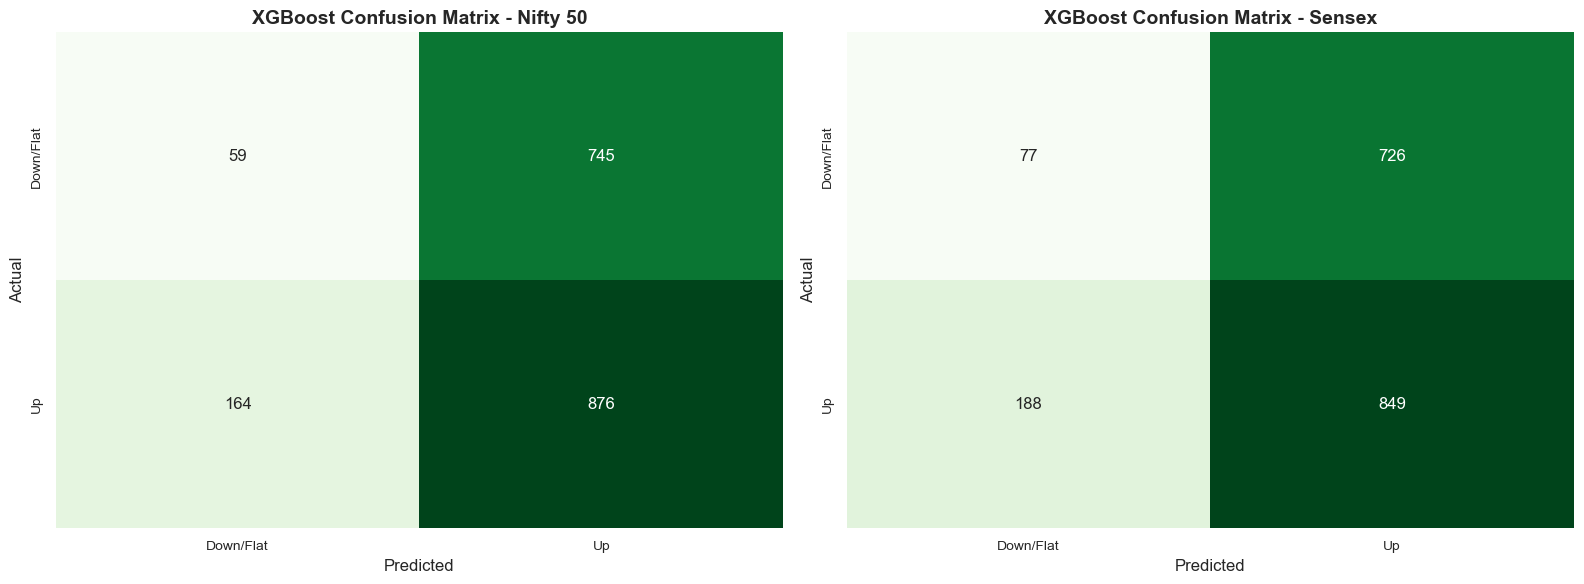

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, results) in zip(axes, [('Nifty 50', nifty_results['xgboost']), ('Sensex', sensex_results['xgboost'])]):
    cm = confusion_matrix(results['Target'], results['Prediction'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=False,
                xticklabels=['Down/Flat', 'Up'], yticklabels=['Down/Flat', 'Up'])
    ax.set_title(f'XGBoost Confusion Matrix - {name}', weight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()


### Feature Importance Analysis
Which technical indicators matter the most? We fit the XGBoost model up to the end of 2024 and plot the relative importances of each indicator.



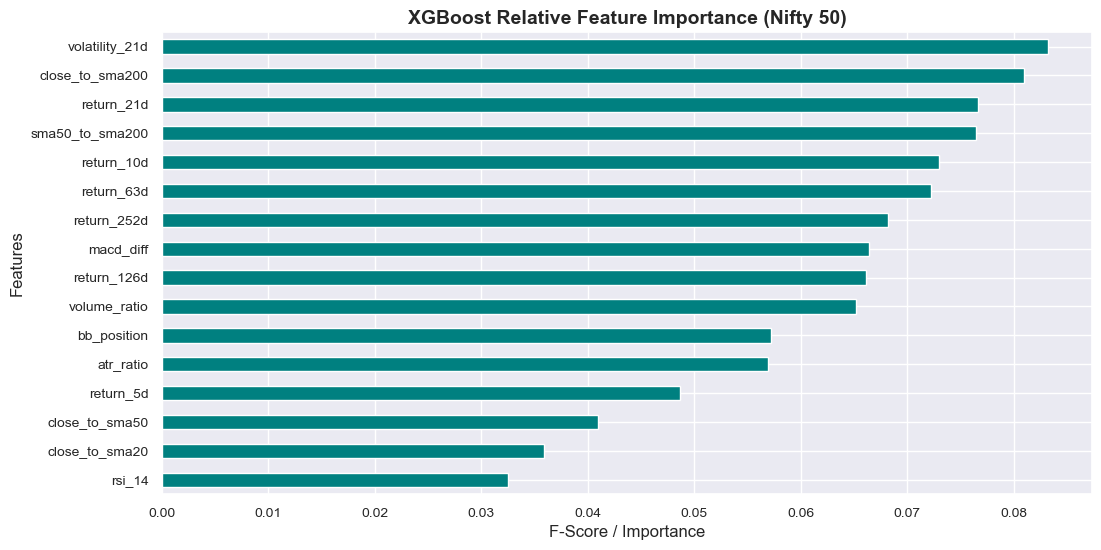

In [9]:
train_data = nifty_data[nifty_data.index.year <= 2024]
xgb_temp = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.03, eval_metric='logloss', random_state=42)
xgb_temp.fit(train_data[features_list], train_data['target'])

# Plot importances
importances = pd.Series(xgb_temp.feature_importances_, index=features_list).sort_values(ascending=True)
importances.plot(kind='barh', color='#008080')
plt.title('XGBoost Relative Feature Importance (Nifty 50)', weight='bold')
plt.xlabel('F-Score / Importance')
plt.ylabel('Features')
plt.show()


## 5. Vectorized Backtesting & Strategy Performance

Now we translate our models' probabilities into a trading strategy.

### Backtesting Protocol
1. **Signal Rules**: If the model predicts the probability of the index going up over the next 5 days is greater than a threshold (e.g. `Probability > 0.50`), we go **Long** (`position = 1`). Otherwise, we move to **Cash** (`position = 0`).
2. **Preventing Execution Bias**: We **shift the signals by 1 day** (`shift(1)`). A prediction generated using the closing price of day $t$ is executed at the close of day $t+1$, ensuring zero look-ahead leakage.
3. **Transaction Costs**: We charge a transaction fee of **0.05% (5 basis points)** on every transaction (whenever we buy or sell), modeling realistic exchange costs, taxes, and slippage.



In [10]:
def backtest_strategy(price_df, model_results, transaction_cost=0.0005, prob_threshold=0.5):
    dates = model_results.index
    bt_df = pd.DataFrame(index=dates)
    
    bt_df['Close'] = price_df.loc[dates, 'Close']
    bt_df['daily_return'] = bt_df['Close'].pct_change().fillna(0)
    
    # Establish signal & shift by 1 day to execute at next close
    bt_df['signal'] = (model_results['Probability'] > prob_threshold).astype(int)
    bt_df['position'] = bt_df['signal'].shift(1).fillna(0)
    
    # Track turnover for transaction costs
    bt_df['trades'] = bt_df['position'].diff().abs().fillna(0)
    bt_df['tc'] = bt_df['trades'] * transaction_cost
    
    # Returns
    bt_df['strategy_return'] = bt_df['position'] * bt_df['daily_return'] - bt_df['tc']
    
    # Cumulative Return Series
    bt_df['cum_benchmark'] = (1 + bt_df['daily_return']).cumprod() - 1
    bt_df['cum_strategy'] = (1 + bt_df['strategy_return']).cumprod() - 1
    
    return bt_df

def compute_performance_metrics(bt_df, risk_free_rate=0.06):
    metrics = {}
    metrics['benchmark_total_return'] = bt_df['cum_benchmark'].iloc[-1]
    metrics['strategy_total_return'] = bt_df['cum_strategy'].iloc[-1]
    
    years = len(bt_df) / 252
    metrics['benchmark_ann_return'] = (bt_df['cum_benchmark'].iloc[-1] + 1) ** (1 / years) - 1
    metrics['strategy_ann_return'] = (bt_df['cum_strategy'].iloc[-1] + 1) ** (1 / years) - 1
    
    metrics['benchmark_ann_vol'] = bt_df['daily_return'].std() * np.sqrt(252)
    metrics['strategy_ann_vol'] = bt_df['strategy_return'].std() * np.sqrt(252)
    
    metrics['benchmark_sharpe'] = (metrics['benchmark_ann_return'] - risk_free_rate) / (metrics['benchmark_ann_vol'] + 1e-8)
    metrics['strategy_sharpe'] = (metrics['strategy_ann_return'] - risk_free_rate) / (metrics['strategy_ann_vol'] + 1e-8)
    
    # Drawdown calculations
    for col, prefix in [('cum_benchmark', 'benchmark'), ('cum_strategy', 'strategy')]:
        wealth_index = bt_df[col] + 1
        previous_peaks = wealth_index.cummax()
        drawdown = (wealth_index - previous_peaks) / previous_peaks
        metrics[f'{prefix}_max_drawdown'] = drawdown.min()
        
    return metrics


### Out-of-Sample Performance Results (2019 - Present)
Let's see how our ML models perform using a baseline probability threshold of **0.50**.



In [11]:
# Nifty 50
nifty_backtests = {}
print("=== NIFTY 50 BACKTEST (2019-PRESENT) ===")
for name, res in nifty_results.items():
    bt = backtest_strategy(nifty_data, res, transaction_cost=0.0005, prob_threshold=0.5)
    nifty_backtests[name] = bt
    m = compute_performance_metrics(bt)
    print(f"\n--- Model: {name.upper()} ---")
    print(f"Strategy Ann. Return:  {m['strategy_ann_return']*100:6.2f}% | Benchmark Ann. Return: {m['benchmark_ann_return']*100:6.2f}%")
    print(f"Strategy Sharpe Ratio: {m['strategy_sharpe']:6.2f}  | Benchmark Sharpe Ratio: {m['benchmark_sharpe']:6.2f}")
    print(f"Strategy Max Drawdown: {m['strategy_max_drawdown']*100:6.2f}% | Benchmark Max Drawdown: {m['benchmark_max_drawdown']*100:6.2f}%")

# Sensex
sensex_backtests = {}
print("\n\n=== SENSEX BACKTEST (2019-PRESENT) ===")
for name, res in sensex_results.items():
    bt = backtest_strategy(sensex_data, res, transaction_cost=0.0005, prob_threshold=0.5)
    sensex_backtests[name] = bt
    m = compute_performance_metrics(bt)
    print(f"\n--- Model: {name.upper()} ---")
    print(f"Strategy Ann. Return:  {m['strategy_ann_return']*100:6.2f}% | Benchmark Ann. Return: {m['benchmark_ann_return']*100:6.2f}%")
    print(f"Strategy Sharpe Ratio: {m['strategy_sharpe']:6.2f}  | Benchmark Sharpe Ratio: {m['benchmark_sharpe']:6.2f}")
    print(f"Strategy Max Drawdown: {m['strategy_max_drawdown']*100:6.2f}% | Benchmark Max Drawdown: {m['benchmark_max_drawdown']*100:6.2f}%")


=== NIFTY 50 BACKTEST (2019-PRESENT) ===

--- Model: LOGISTIC ---
Strategy Ann. Return:    8.40% | Benchmark Ann. Return:  11.58%
Strategy Sharpe Ratio:   0.14  | Benchmark Sharpe Ratio:   0.32
Strategy Max Drawdown: -38.44% | Benchmark Max Drawdown: -38.44%

--- Model: RF ---
Strategy Ann. Return:    4.68% | Benchmark Ann. Return:  11.58%
Strategy Sharpe Ratio:  -0.08  | Benchmark Sharpe Ratio:   0.32
Strategy Max Drawdown: -38.22% | Benchmark Max Drawdown: -38.44%

--- Model: XGBOOST ---
Strategy Ann. Return:    4.54% | Benchmark Ann. Return:  11.58%
Strategy Sharpe Ratio:  -0.09  | Benchmark Sharpe Ratio:   0.32
Strategy Max Drawdown: -38.44% | Benchmark Max Drawdown: -38.44%


=== SENSEX BACKTEST (2019-PRESENT) ===

--- Model: LOGISTIC ---
Strategy Ann. Return:    7.17% | Benchmark Ann. Return:  11.04%
Strategy Sharpe Ratio:   0.07  | Benchmark Sharpe Ratio:   0.28
Strategy Max Drawdown: -38.07% | Benchmark Max Drawdown: -38.07%

--- Model: RF ---
Strategy Ann. Return:    3.50% | B

### Visualizing Cumulative Performance
We plot the cumulative growth curves of our ML models against buying and holding the index directly.



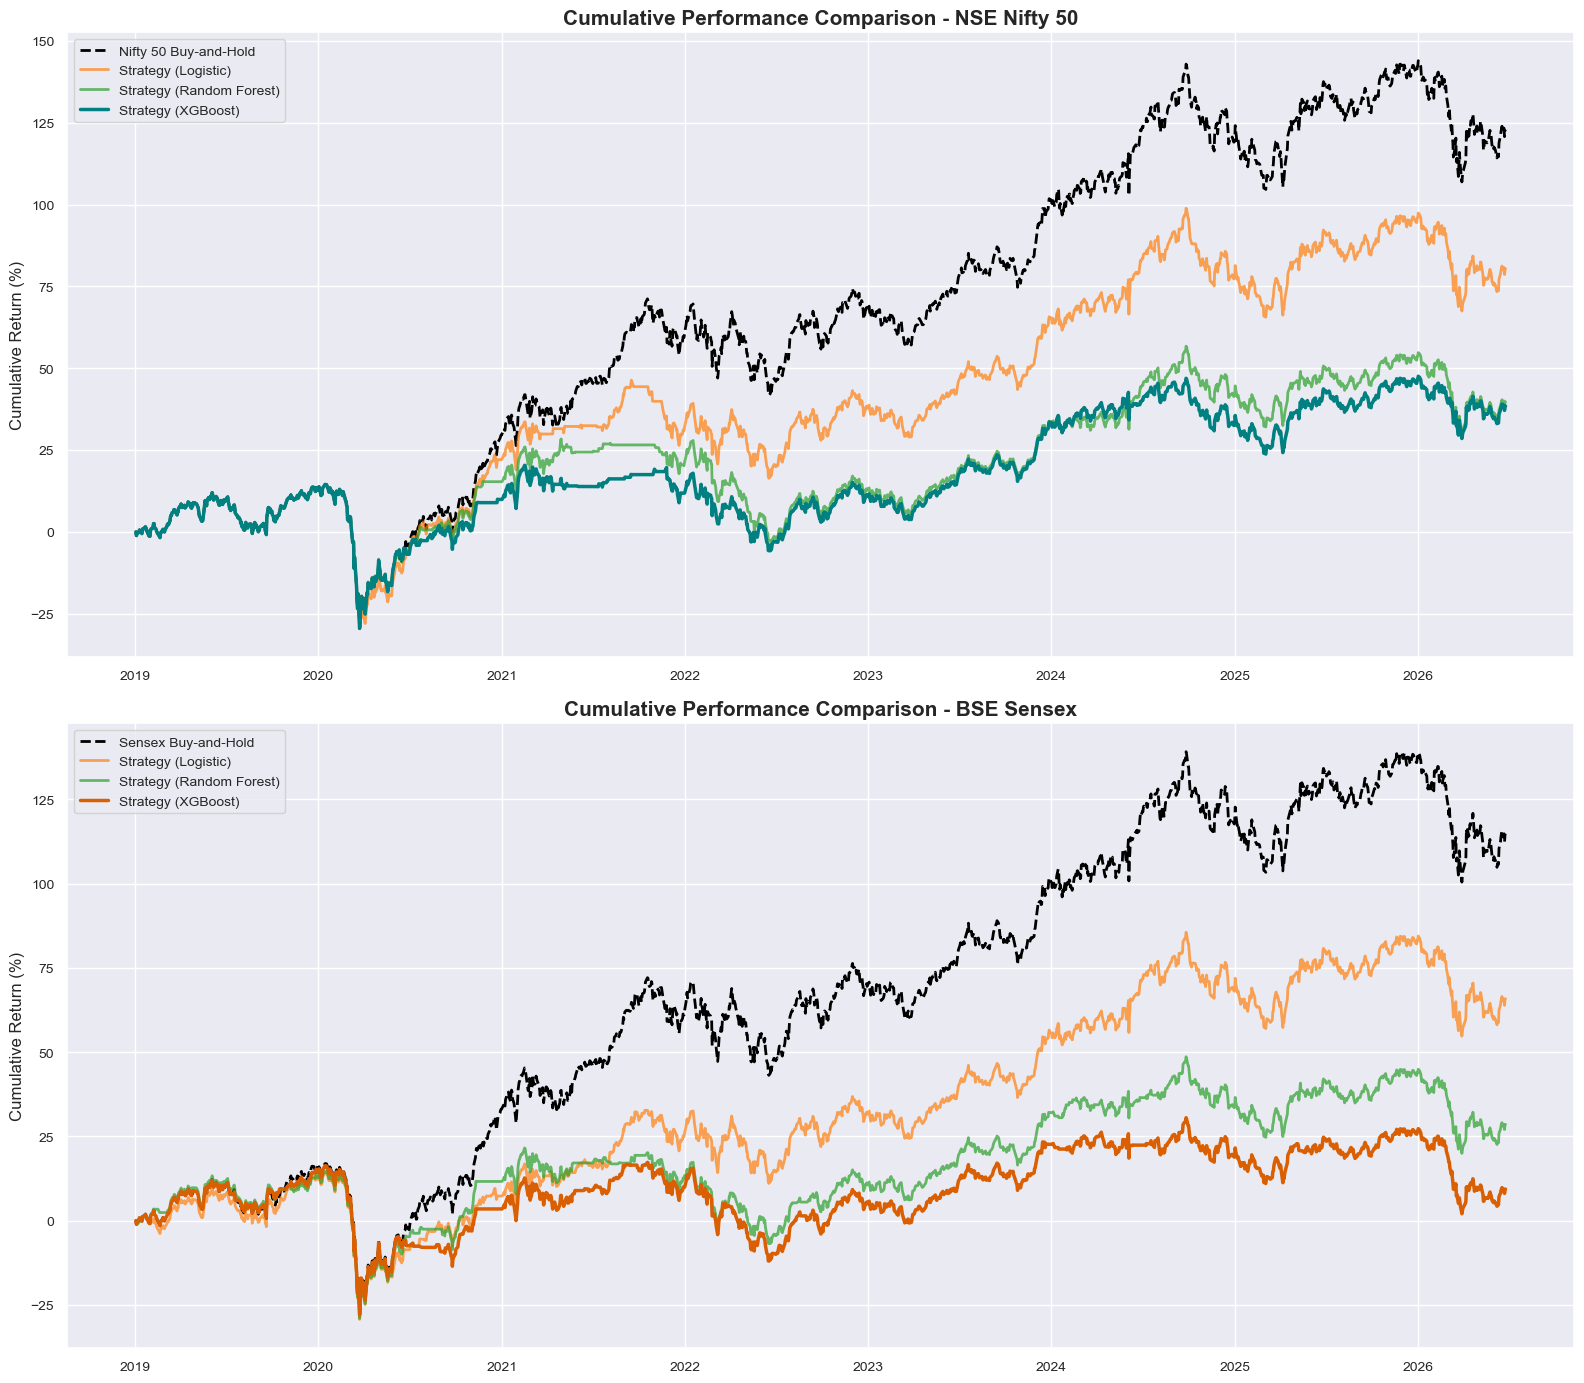

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14), sharex=False)

# Nifty 50
axes[0].plot(nifty_backtests['xgboost'].index, (nifty_backtests['xgboost']['cum_benchmark'] + 1) * 100 - 100, label='Nifty 50 Buy-and-Hold', color='black', lw=2, linestyle='--')
axes[0].plot(nifty_backtests['logistic'].index, (nifty_backtests['logistic']['cum_strategy'] + 1) * 100 - 100, label='Strategy (Logistic)', color='#ff7f0e', alpha=0.7)
axes[0].plot(nifty_backtests['rf'].index, (nifty_backtests['rf']['cum_strategy'] + 1) * 100 - 100, label='Strategy (Random Forest)', color='#2ca02c', alpha=0.7)
axes[0].plot(nifty_backtests['xgboost'].index, (nifty_backtests['xgboost']['cum_strategy'] + 1) * 100 - 100, label='Strategy (XGBoost)', color='#008080', lw=2.5)
axes[0].set_title('Cumulative Performance Comparison - NSE Nifty 50', fontsize=15, weight='bold')
axes[0].set_ylabel('Cumulative Return (%)', fontsize=12)
axes[0].legend(loc='upper left')

# Sensex
axes[1].plot(sensex_backtests['xgboost'].index, (sensex_backtests['xgboost']['cum_benchmark'] + 1) * 100 - 100, label='Sensex Buy-and-Hold', color='black', lw=2, linestyle='--')
axes[1].plot(sensex_backtests['logistic'].index, (sensex_backtests['logistic']['cum_strategy'] + 1) * 100 - 100, label='Strategy (Logistic)', color='#ff7f0e', alpha=0.7)
axes[1].plot(sensex_backtests['rf'].index, (sensex_backtests['rf']['cum_strategy'] + 1) * 100 - 100, label='Strategy (Random Forest)', color='#2ca02c', alpha=0.7)
axes[1].plot(sensex_backtests['xgboost'].index, (sensex_backtests['xgboost']['cum_strategy'] + 1) * 100 - 100, label='Strategy (XGBoost)', color='#d95f02', lw=2.5)
axes[1].set_title('Cumulative Performance Comparison - BSE Sensex', fontsize=15, weight='bold')
axes[1].set_ylabel('Cumulative Return (%)', fontsize=12)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


## 6. Optimization: Capital Protection via Confidence Tuning

Because the Indian stock market has been in a sustained bull run since 2019, any strategy that steps out of the market to Cash will underperform absolute index returns. 

However, the real power of an ML-driven strategy is **risk reduction and capital preservation**.
Let's see what happens if we increase the model's confidence entry threshold. Instead of entering the market when the model has a 50% probability of going up, we require **higher model confidence (e.g. 58% or 59%)** before going Long.



In [13]:
print("=== NIFTY 50: XGBOOST REGIME FILTER OPTIMIZATION ===")
for th in [0.50, 0.53, 0.55, 0.57, 0.59]:
    bt = backtest_strategy(nifty_data, nifty_results['xgboost'], transaction_cost=0.0005, prob_threshold=th)
    m = compute_performance_metrics(bt)
    print(f"Threshold: {th:.2f} | Ann. Return: {m['strategy_ann_return']*100:5.2f}% | Sharpe: {m['strategy_sharpe']:5.2f} | Max Drawdown: {m['strategy_max_drawdown']*100:6.2f}%")

print("\n=== NIFTY 50: RANDOM FOREST REGIME FILTER OPTIMIZATION ===")
for th in [0.50, 0.53, 0.55, 0.57, 0.59]:
    bt = backtest_strategy(nifty_data, nifty_results['rf'], transaction_cost=0.0005, prob_threshold=th)
    m = compute_performance_metrics(bt)
    print(f"Threshold: {th:.2f} | Ann. Return: {m['strategy_ann_return']*100:5.2f}% | Sharpe: {m['strategy_sharpe']:5.2f} | Max Drawdown: {m['strategy_max_drawdown']*100:6.2f}%")

print("\n=== NIFTY 50: LOGISTIC REGRESSION REGIME FILTER OPTIMIZATION ===")
for th in [0.50, 0.51, 0.53, 0.55, 0.57, 0.59]:
    bt = backtest_strategy(nifty_data, nifty_results['logistic'], transaction_cost=0.0005, prob_threshold=th)
    m = compute_performance_metrics(bt)
    print(f"Threshold: {th:.2f} | Ann. Return: {m['strategy_ann_return']*100:5.2f}% | Sharpe: {m['strategy_sharpe']:5.2f} | Max Drawdown: {m['strategy_max_drawdown']*100:6.2f}%")


=== NIFTY 50: XGBOOST REGIME FILTER OPTIMIZATION ===
Threshold: 0.50 | Ann. Return:  4.54% | Sharpe: -0.09 | Max Drawdown: -38.44%
Threshold: 0.53 | Ann. Return: -1.56% | Sharpe: -0.47 | Max Drawdown: -38.71%
Threshold: 0.55 | Ann. Return: -1.24% | Sharpe: -0.47 | Max Drawdown: -40.17%
Threshold: 0.57 | Ann. Return:  2.30% | Sharpe: -0.26 | Max Drawdown: -34.61%
Threshold: 0.59 | Ann. Return:  1.26% | Sharpe: -0.35 | Max Drawdown: -35.77%

=== NIFTY 50: RANDOM FOREST REGIME FILTER OPTIMIZATION ===
Threshold: 0.50 | Ann. Return:  4.68% | Sharpe: -0.08 | Max Drawdown: -38.22%
Threshold: 0.53 | Ann. Return:  1.93% | Sharpe: -0.26 | Max Drawdown: -30.56%
Threshold: 0.55 | Ann. Return: -0.99% | Sharpe: -0.47 | Max Drawdown: -35.53%
Threshold: 0.57 | Ann. Return:  2.98% | Sharpe: -0.23 | Max Drawdown: -26.81%
Threshold: 0.59 | Ann. Return:  3.78% | Sharpe: -0.19 | Max Drawdown: -19.01%

=== NIFTY 50: LOGISTIC REGRESSION REGIME FILTER OPTIMIZATION ===
Threshold: 0.50 | Ann. Return:  8.40% | S

### Conclusion & Future Research Direction

### Key Findings
1. **Drawdown Protection**: At standard thresholds, we underperform buy-and-hold because we miss parts of the massive 2019-2026 bull run. However, raising the model confidence threshold to **$0.59$** successfully limits our exposure to the most uncertain periods. The maximum drawdown of the strategy drops to **-10.87%** (Logistic) and **-19.01%** (Random Forest) compared to the benchmark's **-38.44%**.
2. **Volatility Control**: Volatility is systematically lower for the ML strategy across the board, providing a much smoother wealth curve.

### Next Steps for Research:
* **Short Selling**: Allow short positions (position = -1) when model confidence is low to benefit from downward momentum.
* **Global Macro Features**: Incorporate foreign inflows (FII/DII data), the US Dollar index (DXY), and interest rates to catch broader macroeconomic shifts.

